In [12]:
from functools import partial
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# Crazy Gaussians

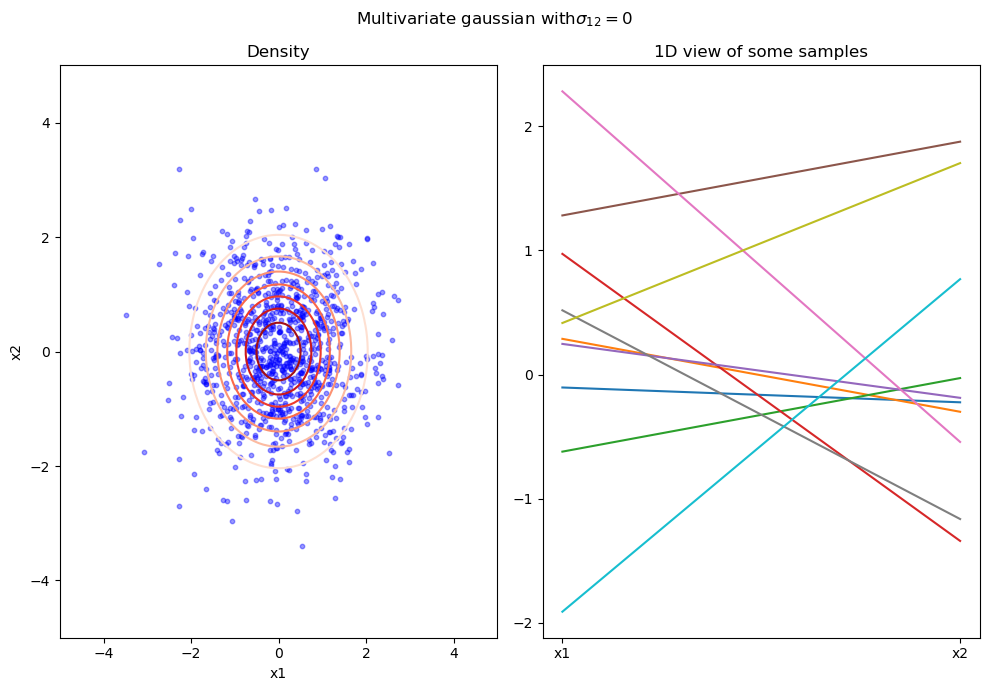

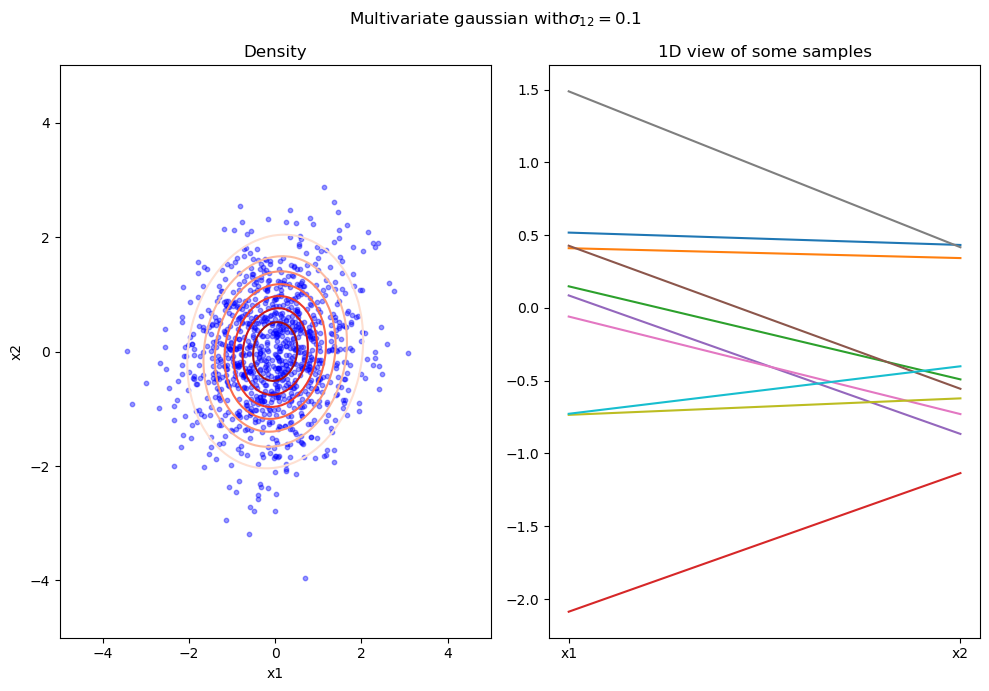

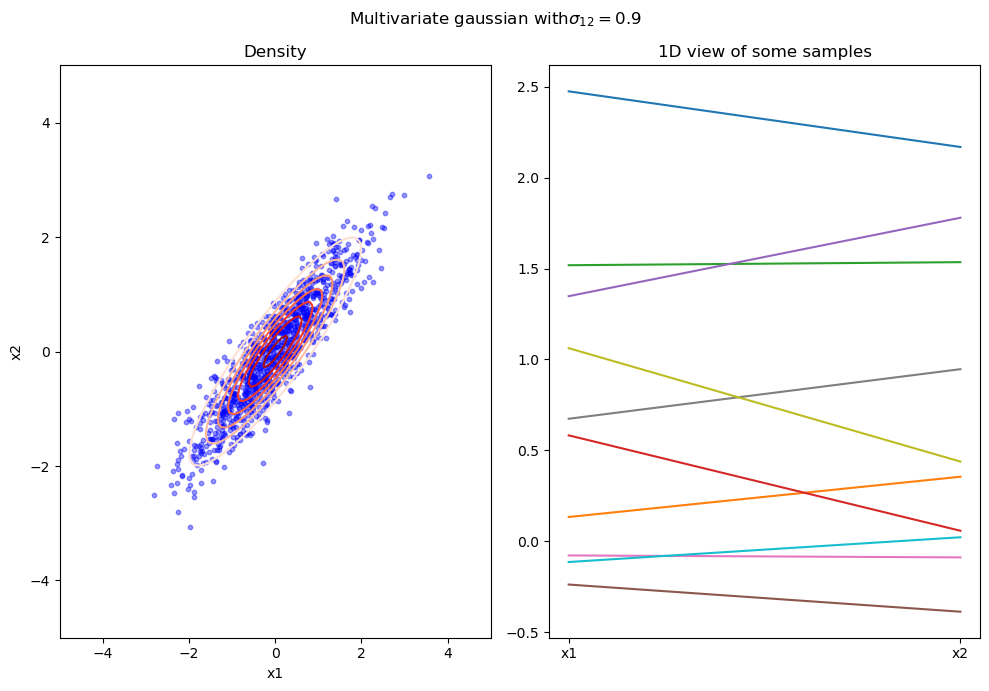

In [13]:
mean = np.zeros(2)
for cov12 in (0, 0.1, 0.9):
    fig, axes = plt.subplots(1, 2, figsize=(10, 7))
    axes = axes.flatten()

    cov = np.array([[1, cov12], [cov12, 1]])
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    x_grid, y_grid = np.meshgrid(x, y)
    pos = np.dstack((x_grid, y_grid))
    dens = st.multivariate_normal.pdf(pos, mean, cov)
    samples = np.random.multivariate_normal(mean, cov, 1000)
    axes[0].contour(x_grid, y_grid, dens, cmap="Reds")
    axes[0].scatter(samples[:, 0], samples[:, 1], alpha=0.4, s=10, c="blue")
    for sample in samples[:10]:
        axes[1].plot(sample)
    axes[0].set_title("Density")
    axes[0].set_xlabel("x1")
    axes[0].set_ylabel("x2")
    axes[1].set_title("1D view of some samples")
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(["x1", "x2"])
    fig.suptitle("Multivariate gaussian with$\\sigma_{12} = " + str(cov12) + "$")
    plt.tight_layout()
    plt.show()

Higher covariance between dimensions - dimensions are more "aligned" - they tend to increase / discase together.

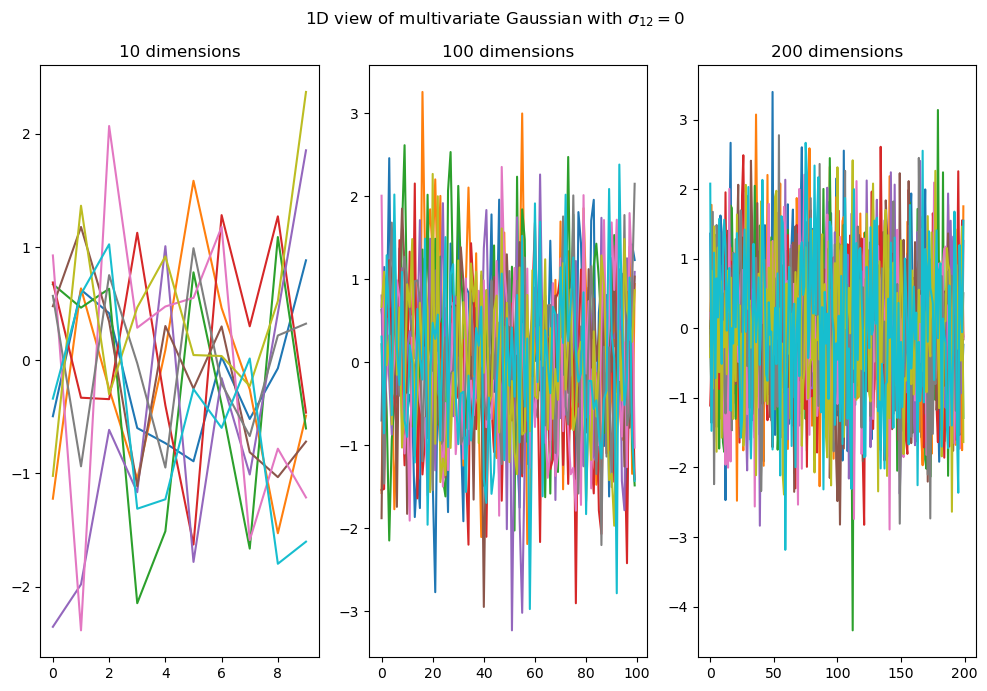

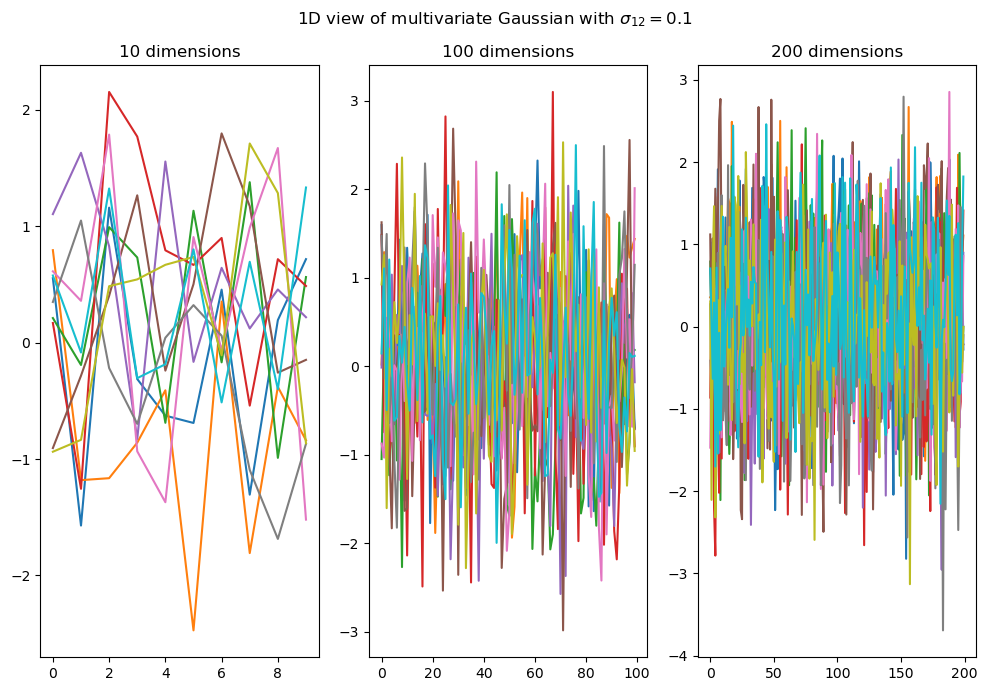

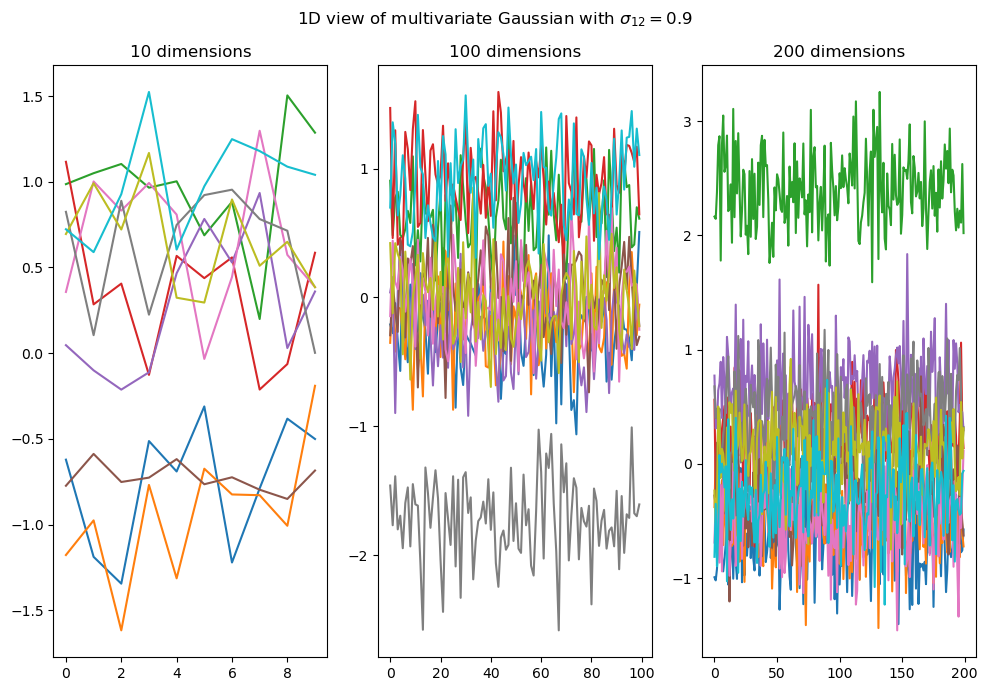

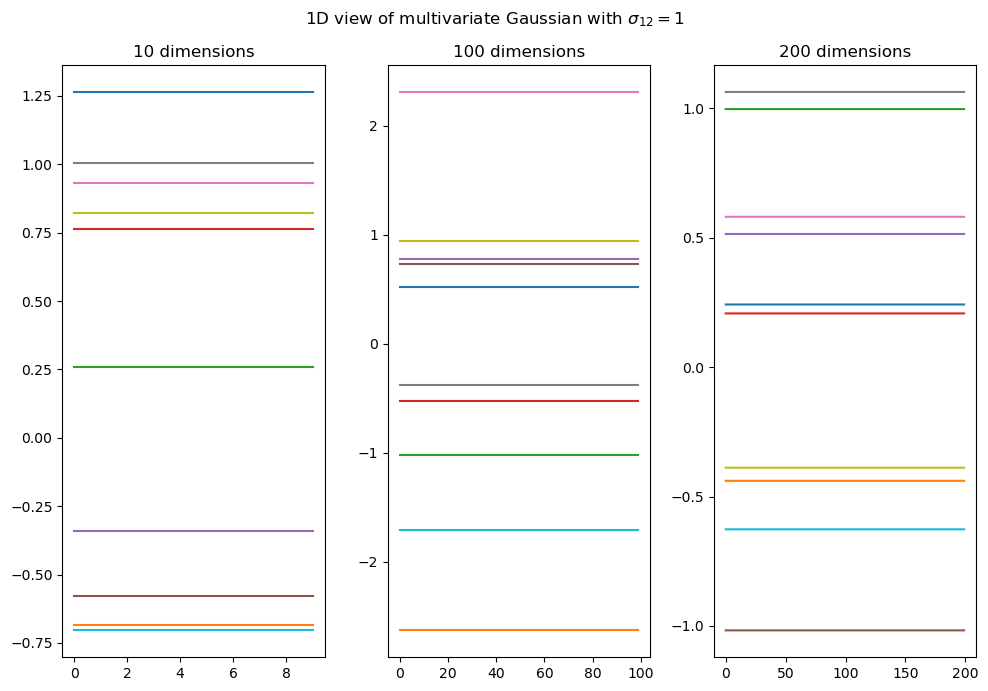

In [14]:
d_to_try = (10, 100, 200)
n_samples = 10
for cross_cov in (0, 0.1, 0.9, 1):
    fig, axes = plt.subplots(1, len(d_to_try), figsize=(10, 7))
    axes = axes.flatten()
    for i, d in enumerate(d_to_try):
        mean = np.zeros(d)
        cov = np.ones((d, d)) * cross_cov
        cov = cov * (1 - np.eye(d, d)) + np.eye(d, d)  # set diagonal to 1
        samples = np.random.multivariate_normal(mean, cov, n_samples)
        for sample in samples:
            axes[i].plot(sample)
            axes[i].set_title(f"{d} dimensions")
    fig.suptitle(
        "1D view of multivariate Gaussian with $\\sigma_{12} = " + str(cross_cov) + "$"
    )
    plt.tight_layout()
    plt.show()

Higher covariance - flatter 1D representations

# Covariance Function (Kernel)

In [15]:
def linear_kernel(X, sigma=1):
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    G = X @ X.T
    return sigma**2 * G


def rbf_kernel(X, sigma=1, l=1):
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    D = pairwise_distances(X, metric="euclidean")
    return sigma**2 * np.exp(-1 / (2 * l**2) * D**2)


def periodic_kernel(X, sigma=1, l=1, p=1):
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    D = pairwise_distances(X, metric="euclidean")
    return sigma**2 * np.exp(-1 / l**2 * np.sin(np.pi * D / p) ** 2)

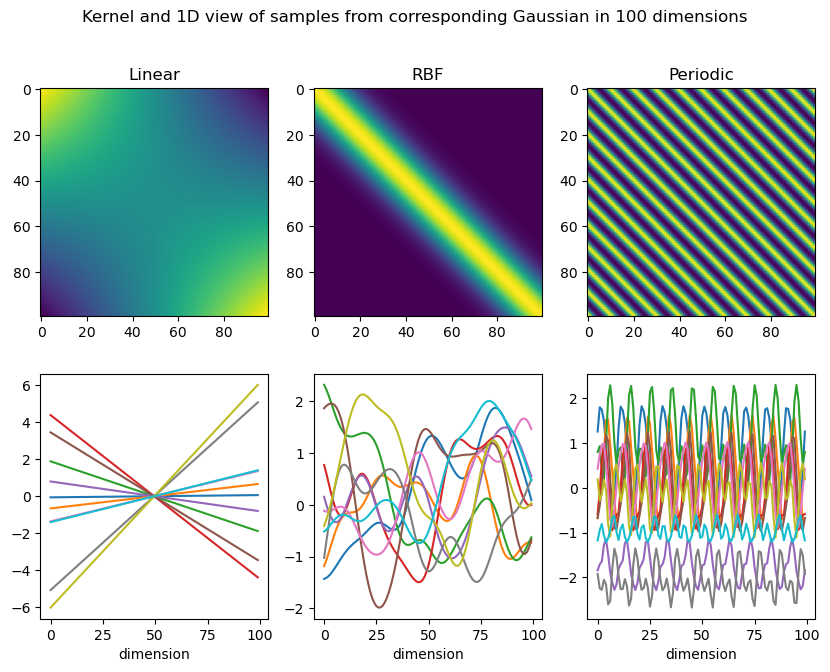

In [16]:
X = np.linspace(-5, 5, 100)
# NOTE: shuffling / non-linearly spacing of x dimensions will break nice visualizations
#       you can plot against x directly
# X = np.random.uniform(-5,5,100) 
d = len(X)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
kernels = {"Linear": linear_kernel, "RBF": rbf_kernel, "Periodic": periodic_kernel}
for i, (name, kernel) in enumerate(kernels.items()):
    K = kernel(X)
    axes[i].imshow(K)
    axes[i].set_title(name)
    mean = np.zeros(d)
    samples = np.random.multivariate_normal(mean, K, n_samples)
    for sample in samples:
        axes[i + 3].plot(sample)
        axes[i + 3].set_xlabel("dimension")
        # axes[i+6].plot(X, sample)
        # axes[i+6].set_xlabel("x")
plt.suptitle(
    f"Kernel and 1D view of samples from corresponding Gaussian in {d} dimensions"
)
plt.show()

### TODO: play with params

# Gaussian Process and Regression

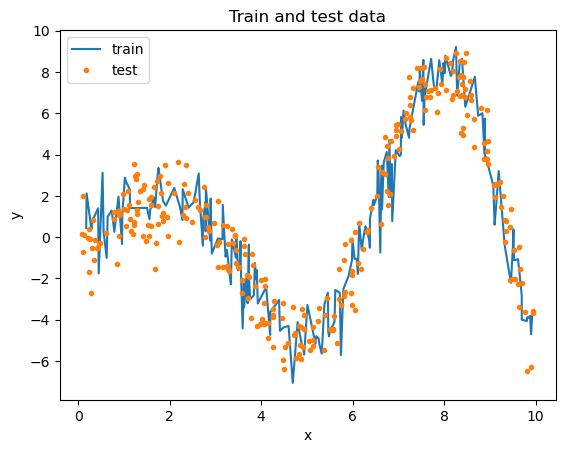

In [17]:
N = 500
test_prop = 0.6
sigma = 1

def latent_f(x):
    # return 20*np.cos(5*x)+ x**2
    return x * np.sin(x)


x = np.sort(np.random.random(N).reshape(-1, 1) * 10, axis=0)
y = latent_f(x) + np.random.randn(N).reshape(-1, 1) * sigma

idx_test = np.random.choice(N, size=int(test_prop * N), replace=False)

test_mask = np.zeros(N).astype(bool)
test_mask[idx_test] = True

x_test = x[test_mask]
y_test = y[test_mask]

x_train = x[~test_mask]
y_train = y[~test_mask]

n_test = len(x_test)
n_train = len(x_train)

plt.plot(x_train, y_train, "-", label="train")
plt.plot(x_test, y_test, ".", label="test")
plt.title("Train and test data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [18]:
def fit_gp(x_train, y_train, x_test, kernel, sigma):

    n_train = len(x_train)

    K_full = kernel(np.vstack([x_train, x_test]))

    K_train = K_full[:n_train, :n_train]  # K
    K_train_test = K_full[:n_train, n_train:]  # K*
    K_test = K_full[n_train:, n_train:]  # K**

    # NOTE: analytical form after marginalization
    K_train_sigma_inv = np.linalg.inv((K_train + sigma**2 * np.eye(n_train)))
    mu_gp = (K_train_test.T @ K_train_sigma_inv @ y_train).reshape(-1)
    K_gp = K_test - K_train_test.T @ K_train_sigma_inv @ K_train_test

    return mu_gp, K_gp

In [19]:
mu_gp, K_gp = fit_gp(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    # kernel=partial(rbf_kernel, sigma=1,l=1),
    kernel=partial(periodic_kernel, sigma=1,l=1,p=10),
    sigma=sigma,
)

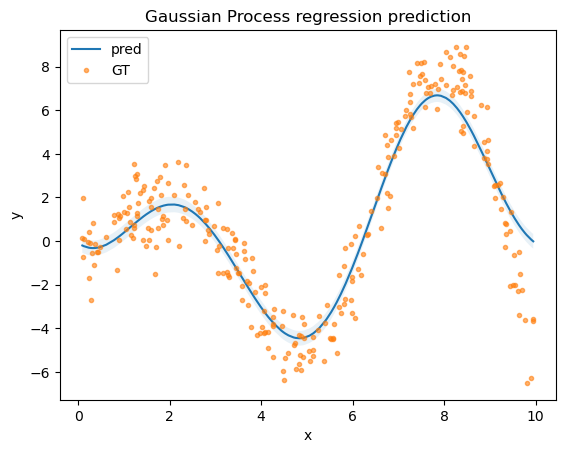

In [20]:
# samples = np.random.multivariate_normal(mu_gp, K_gp, 1)
# for sample in samples:
# plt.plot(x_test, sample, '-', label="pred")
plt.plot(x_test, mu_gp, "-", label="pred")
confidence_int = 2 * np.sqrt(K_gp.diagonal())
plt.fill_between(
    x_test.flatten(), mu_gp - confidence_int, mu_gp + confidence_int, alpha=0.1
)

plt.plot(x_test, y_test, ".", label="GT", alpha=0.6)
plt.legend()
plt.title("Gaussian Process regression prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

And try on real data:

In [21]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    housing["data"], housing["target"], test_size=0.2
)

In [22]:
gpr = Pipeline(
    [("scale", StandardScaler()),("gpr", GaussianProcessRegressor(kernel=RBF()))]
)
gpr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('gpr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",RBF(length_scale=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined opt

In [23]:
# gpr.fit(X_train, y_train) # NOTE: it is super slow since matrix inversion is O(n^3)

Text(0, 0.5, 'MedHouseVal')

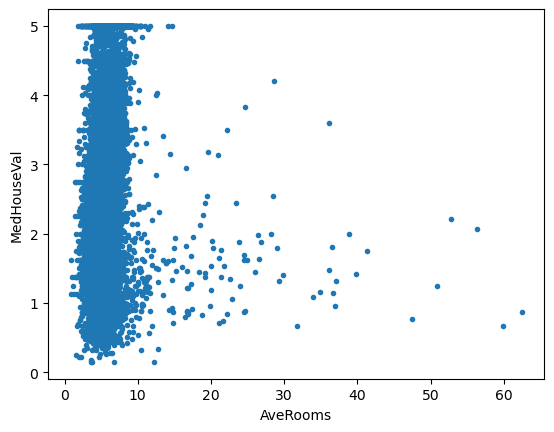

In [24]:
i_feature = 2
plt.plot(X_train[:,i_feature], y_train, '.')
plt.xlabel(housing["feature_names"][i_feature])
plt.ylabel(housing["target_names"][0])